# 호환 사본 안내
원본 보존용 호환 사본. 상위 폴더 COMPATIBILITY.md를 먼저 확인하세요. Kafka 설치 셀은 Linux/Colab 전용입니다. Windows 기본 실습은 week07_structured_streaming_lab.ipynb를 사용하세요.

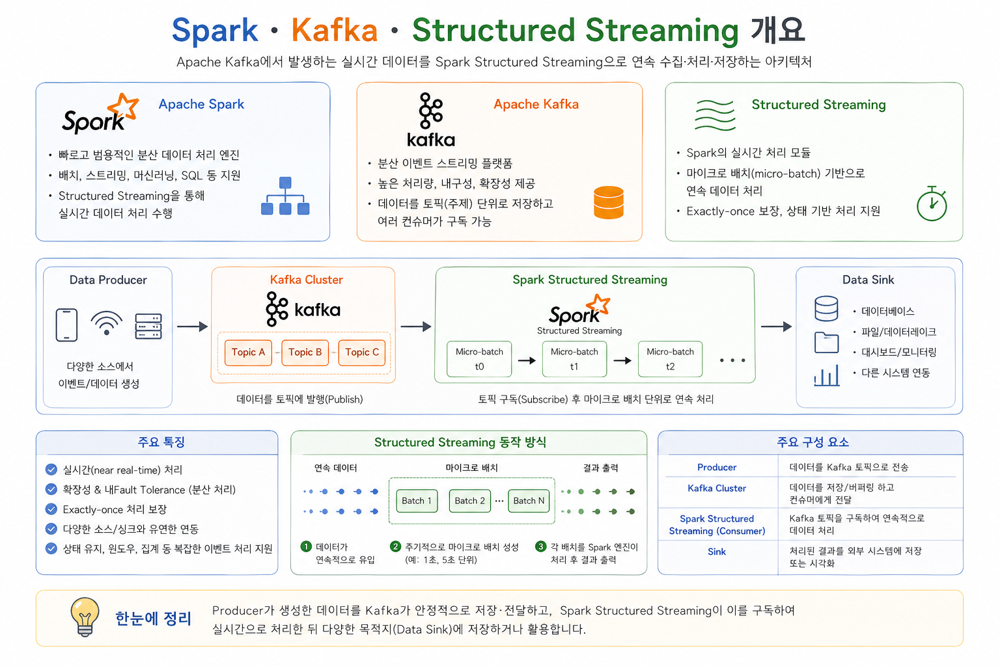

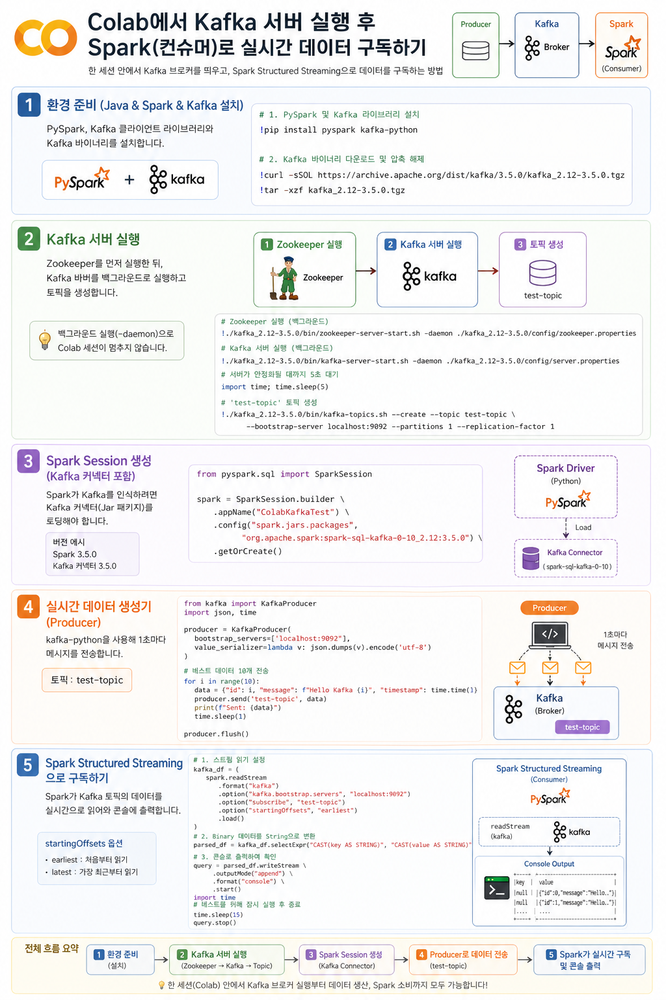

1. 환경 준비 (Java & Spark & Kafka 설치)
Colab 리눅스 환경에 Kafka를 설치하고 PySpark 세션을 구성합니다.

In [ ]:
# 1. PySpark 및 Kafka 라이브러리 설치
!pip install pyspark==3.5.3 kafka-python==2.0.2

# 2. Kafka 바이너리 다운로드 및 압축 해제
!curl -sSOL https://archive.apache.org/dist/kafka/3.5.0/kafka_2.12-3.5.0.tgz
!tar -xzf kafka_2.12-3.5.0.tgz

2. Kafka 서버 실행
Kafka는 관리자인 Zookeeper가 먼저 떠야 실행됩니다. Colab에서는 백그라운드(&)로 실행해야 코드가 멈추지 않습니다.

In [ ]:
# 1. 기존 Kafka/Zookeeper 프로세스 종료 (Colab 셀에서 실행)
!pkill -f 'kafka.Kafka'
!pkill -f 'org.apache.zookeeper.server.ZooKeeperServerMain'
import time
time.sleep(3) # 프로세스 종료 대기

# 2. Zookeeper 및 Kafka 재시작 (백그라운드)
!./kafka_2.12-3.5.0/bin/zookeeper-server-start.sh -daemon ./kafka_2.12-3.5.0/config/zookeeper.properties
!./kafka_2.12-3.5.0/bin/kafka-server-start.sh -daemon ./kafka_2.12-3.5.0/config/server.properties
time.sleep(10) # 서버 시작 대기

print("Kafka 서버를 재시작했습니다.")

# Kafka 및 Zookeeper 프로세스 확인
!jps

# 토픽이 없을 때만 생성하도록 '--if-not-exists' 옵션을 추가합니다.
!./kafka_2.12-3.5.0/bin/kafka-topics.sh --create --if-not-exists --topic test-topic --bootstrap-server localhost:9092 --partitions 1 --replication-factor 1

In [ ]:
# 모든 토픽목록 확인: Colab 환경 기준 경로
!./kafka_2.12-3.5.0/bin/kafka-topics.sh --list --bootstrap-server localhost:9092

3. Spark Session 생성 (Kafka 커넥터 포함)
Spark가 Kafka를 인식하려면 전용 Jar 패키지를 로드해야 합니다.

In [ ]:
from pyspark.sql import SparkSession

# PySpark 3.5.3 / Scala 2.12와 Kafka 커넥터 버전 일치
# 설치 버전을 바꾸면 런타임을 재시작한 뒤 세션을 생성하세요.
spark = SparkSession.builder \
    .appName("ColabKafkaTest") \
    .config("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.3") \
    .getOrCreate()

4. 실시간 데이터 생성기 (Producer)
구독할 데이터가 있어야 확인이 가능하므로, 1초마다 메시지를 쏘는 간단한 루프를 만듭니다.

In [ ]:
%%writefile kafka_producer_script.py
from kafka import KafkaProducer
import json
import time
import random

producer = KafkaProducer(
    bootstrap_servers=['127.0.0.1:9092'],
    value_serializer=lambda v: json.dumps(v).encode('utf-8'),
    acks='all',
    retries=5
)

for i in range(120):
    data = {
        "id": i,
        "message": f"Hello Kafka {i} (random: {random.randint(0, 100)})",
        "timestamp": time.time()
    }

    future = producer.send('test-topic', data)
    result = future.get(timeout=10)

    print(f"Sent: {data} -> partition={result.partition}, offset={result.offset}", flush=True)
    time.sleep(1)

producer.flush()
producer.close()

print("데이터 20개를 'test-topic'으로 전송 완료했습니다.", flush=True)

이전 셀의 `kafka_producer_script.py`를 백그라운드에서 실행합니다. `&`를 사용하여 이 셀이 완료된 후에도 스크립트가 계속 실행되도록 합니다.

In [ ]:
print("Starting Kafka producer in background...")
# 백그라운드에서 Kafka 생산자 스크립트 실행 (nohup을 사용하여 완전히 분리)
!nohup python -u kafka_producer_script.py > producer_output.log 2>&1 &

!sleep 3
!tail -n 20 producer_output.log

5. Spark Structured Streaming으로 구독하기
이제 처음에 작성하셨던 코드로 데이터를 읽어옵니다.

# Display Advertising


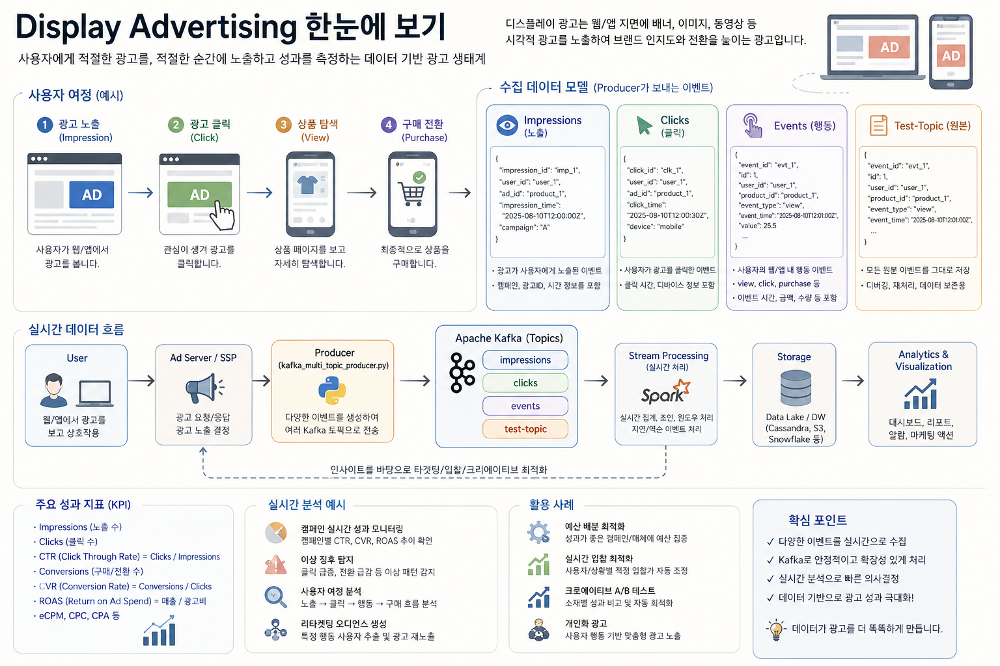

# Spark Structured Streaming 핵심 예제


- Event Time vs Processing Time 비교
- Watermark 메커니즘 및 Window Aggregation
- Stateful Processing vs Stateless Processing
- Checkpoint 예제
- Output Modes 비교
- Stream-Stream Join
- 백그라운드 Kafka Producer와 호환되는 공통 메시지 스키마

> 실행 순서: Kafka/Zookeeper 실행 → SparkSession 생성 → 아래 Producer/Topic 생성 → 원하는 예제 실행

[데이터사이언스 연구실](https://www.datasciencelabs.org/)



In [ ]:
# [공통 유틸] 기존 스트리밍 쿼리 정리 및 Kafka topic 생성 함수

from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
)
import os, shutil, time, json, subprocess
import pandas as pd # pandas 라이브러리를 임포트합니다.

KAFKA_HOME = "./kafka_2.12-3.5.0"
BOOTSTRAP = "localhost:9092"

def stop_all_streams():
    # Colab/Jupyter에서 이전 Structured Streaming query가 남아 있을 때 안전하게 정리합니다.
    for q in spark.streams.active:
        print(f"Stopping active query: {q.name}")
        q.stop()
    time.sleep(2)

def reset_path(path: str):
    # 실습 재실행을 위해 checkpoint/output 디렉토리를 삭제합니다.
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Deleted: {path}")

def create_topic(topic: str, partitions: int = 1, replication_factor: int = 1):
    # Kafka topic이 없으면 생성합니다. 이미 있으면 오류를 무시합니다.
    cmd = [
        f"{KAFKA_HOME}/bin/kafka-topics.sh",
        "--create",
        "--if-not-exists",
        "--bootstrap-server", BOOTSTRAP,
        "--topic", topic,
        "--partitions", str(partitions),
        "--replication-factor", str(replication_factor)
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout.strip() or result.stderr.strip())

def debug_batch(df, epoch_id):
    print(f"\n==== Batch {epoch_id} ====")
    try:
        # DataFrame이 비어 있는지 먼저 확인하여 불필요한 처리를 피합니다.
        if df.isEmpty():
            print("이 배치에는 데이터가 없습니다.")
            return

        # 'window_start' 컬럼이 존재하는지 확인하여 동적으로 정렬 기준을 변경합니다.
        if "window_start" in df.columns:
            sorted_df = df.orderBy("window_start")
        elif "event_time_ts" in df.columns:
            sorted_df = df.orderBy("event_time_ts")
        else:
            sorted_df = df # 시간 관련 컬럼이 없으면 정렬하지 않습니다.

        # 데이터를 Pandas DataFrame으로 변환하여 출력 (show()의 InterruptedException 방지)
        # toPandas()는 드라이버로 데이터를 수집하므로, 큰 배치에서는 limit를 낮게 유지하는 것이 중요합니다.
        pandas_df = sorted_df.limit(20).toPandas()

        if not pandas_df.empty:
            from IPython.display import display # Colab의 display 함수를 임포트합니다.
            display(pandas_df) # Pandas DataFrame을 Colab에 보기 좋게 출력합니다.
        else:
            print("이 배치에는 데이터가 없습니다.")
    except Exception as e:
        print(f"배치 {epoch_id} 표시 중 오류 발생: {e}")

for t in ["test-topic", "events", "impressions", "clicks"]:
    create_topic(t)

print("현재 Kafka topic 목록:")
!./kafka_2.12-3.5.0/bin/kafka-topics.sh --list --bootstrap-server localhost:9092

## 0. 백그라운드 Kafka Producer: 모든 예제와 호환되는 메시지 생성

기존 `test-topic`과 추가 실습용 `events`, `impressions`, `clicks` 토픽에 동시에 메시지를 발행합니다.

일부 메시지는 의도적으로 30초~2분 늦은 Event Time을 넣어 Watermark와 Late Data 처리를 관찰할 수 있게 했습니다.

In [ ]:
%%writefile kafka_multi_topic_producer.py
from kafka import KafkaProducer
import json, time, random
from datetime import datetime, timedelta, timezone

BOOTSTRAP = "127.0.0.1:9092"

producer = KafkaProducer(
    bootstrap_servers=[BOOTSTRAP],
    value_serializer=lambda v: json.dumps(v, ensure_ascii=False).encode("utf-8"),
    key_serializer=lambda v: str(v).encode("utf-8"),
    acks="all",
    retries=5,
    linger_ms=50
)

def now_iso(offset_seconds=0):
    return (datetime.now(timezone.utc) + timedelta(seconds=offset_seconds)).isoformat()

event_types = ["view", "click", "purchase"]
users = [f"user_{i}" for i in range(1, 6)]
products = [f"product_{i}" for i in range(1, 4)]

i = 0
print("Kafka multi-topic producer started. Press stop/interrupt or pkill to terminate.", flush=True)

while True:
    late_offset = random.choice([0, 0, 0, -30, -60, -120])
    user_id = random.choice(users)
    product_id = random.choice(products)
    event_type = random.choice(event_types)

    event = {
        "event_id": f"evt_{i}",
        "id": i,
        "user_id": user_id,
        "product_id": product_id,
        "event_type": event_type,
        "message": f"{event_type} event {i}",
        "event_time": now_iso(late_offset),
        "processing_hint_time": now_iso(0),
        "timestamp": time.time(),
        "value": round(random.uniform(1, 100), 2),
        "quantity": random.randint(1, 5),
        "price": round(random.uniform(1000, 10000), 2)
    }

    producer.send("test-topic", key=user_id, value=event)
    producer.send("events", key=user_id, value=event)

    impression = {
        "impression_id": f"imp_{i}",
        "user_id": user_id,
        "ad_id": product_id,
        "impression_time": event["event_time"],
        "campaign": random.choice(["A", "B"])
    }
    producer.send("impressions", key=user_id, value=impression)

    if random.random() < 0.7:
        click_delay = random.randint(0, 90)
        click = {
            "click_id": f"clk_{i}",
            "user_id": user_id,
            "ad_id": product_id,
            "click_time": now_iso(late_offset + click_delay),
            "device": random.choice(["mobile", "web"])
        }
        producer.send("clicks", key=user_id, value=click)

    if i % 10 == 0:
        producer.flush()
        print(f"sent #{i}: {event}", flush=True)

    i += 1
    time.sleep(1)

In [ ]:
# Producer를 백그라운드에서 실행합니다.
# 이미 실행 중인 producer가 있으면 먼저 종료합니다.
!pkill -f kafka_multi_topic_producer.py || true
!nohup python -u kafka_multi_topic_producer.py > producer_multi.log 2>&1 &

!sleep 5
!tail -n 20 producer_multi.log

In [ ]:
# [공통 스키마 및 Kafka Reader] events 토픽을 구조화된 스트림으로 읽기

# Kafka 메시지 페이로드의 스키마를 정의합니다.
# multi-topic producer에서 전송하는 복합 데이터 구조와 일치해야 합니다.
event_schema = StructType([
    StructField("event_id", StringType(), True),
    StructField("id", IntegerType(), True),
    StructField("user_id", StringType(), True),
    StructField("product_id", StringType(), True),
    StructField("event_type", StringType(), True),
    StructField("message", StringType(), True),
    StructField("event_time", StringType(), True), # ISO 8601 형식의 이벤트 시간
    StructField("processing_hint_time", StringType(), True),
    StructField("timestamp", DoubleType(), True), # Unix 타임스탬프 (producer의 local time)
    StructField("value", DoubleType(), True),
    StructField("quantity", IntegerType(), True),
    StructField("price", DoubleType(), True),
])

# Kafka에서 'events' 토픽의 스트림 데이터를 읽기 위한 설정을 정의합니다.
raw_events = (
    spark.readStream
    .format("kafka") # Kafka 소스 사용을 지정
    .option("kafka.bootstrap.servers", BOOTSTRAP) # Kafka 브로커 주소 설정 (BOOTSTRAP 변수 사용)
    .option("subscribe", "events") # 'events' 토픽을 구독
    .option("startingOffsets", "latest") # 새로 들어오는 메시지만 읽도록 설정 (이전 메시지 무시)
    .load() # 스트림 로드 시작
)

# Kafka에서 읽은 원시 데이터를 파싱하고 필요한 컬럼을 추출 및 변환합니다.
events_df = (
    raw_events
    .select(
        F.col("key").cast("string").alias("kafka_key"), # Kafka 메시지의 키를 문자열로 변환하여 'kafka_key' 컬럼으로 지정
        F.col("timestamp").alias("kafka_processing_time"), # Kafka가 메시지를 받은 시간 ('kafka_processing_time'은 Kafka 내부 타임스탬프)
        F.from_json(F.col("value").cast("string"), event_schema).alias("data") # Kafka 메시지 값을 JSON으로 파싱하여 'data' 구조체로 변환
    )
    .select("kafka_key", "kafka_processing_time", "data.*") # 'data' 구조체의 모든 필드를 상위 레벨 컬럼으로 확장
    .withColumn("event_time_ts", F.to_timestamp("event_time")) # ISO 8601 형식의 'event_time'을 TimestampType으로 변환하여 'event_time_ts' 컬럼 생성
    .withColumn("producer_time_ts", F.to_timestamp("processing_hint_time")) # 'processing_hint_time'을 TimestampType으로 변환하여 'producer_time_ts' 컬럼 생성
)

# 변환된 DataFrame의 스키마를 출력하여 확인합니다.
events_df.printSchema()

## 1. Event Time과 Processing Time 비교

- **Event Time**: 데이터가 실제 발생한 시각입니다.
- **Processing Time**: Spark가 Kafka 메시지를 읽고 처리하는 시스템 시각입니다.
- 지연 데이터가 있으면 Processing Time 기준 집계는 도착 순서에 민감하고, Event Time 기준 집계는 원래 발생 시각 기준으로 재현 가능한 분석을 수행할 수 있습니다.

In [ ]:
# Event Time과 Processing Time을 나란히 출력하여 지연 정도를 확인합니다.

stop_all_streams()
reset_path("/tmp/ckpt/event_vs_processing_time")

event_vs_processing_df = (
    events_df
    .withColumn("processing_time", F.current_timestamp())
    .withColumn(
        "latency_seconds",
        F.col("processing_time").cast("long") - F.col("event_time_ts").cast("long")
    )
    .select(
        "event_id", "user_id", "event_type",
        "event_time_ts", "producer_time_ts", "kafka_processing_time",
        "processing_time", "latency_seconds"
    )
)

query_event_time = (
    event_vs_processing_df.writeStream
    .format("memory")
    .queryName("event_vs_processing_time")
    .outputMode("append")
    .option("checkpointLocation", "/tmp/ckpt/event_vs_processing_time")
    .trigger(processingTime="5 seconds")
    .start()
)

time.sleep(15)
spark.sql("""
SELECT event_id, user_id, event_type, event_time_ts, processing_time, latency_seconds
FROM event_vs_processing_time
ORDER BY processing_time DESC
LIMIT 20
""").show(truncate=False)

query_event_time.stop()

## 2. Watermark 메커니즘 및 Window Aggregation

Watermark는 `관측된 최대 Event Time - 허용 지연 시간`으로 계산되는 기준선입니다.  
이 기준선보다 오래된 이벤트는 더 이상 결과에 반영하지 않고, Spark는 오래된 window state를 정리할 수 있습니다.

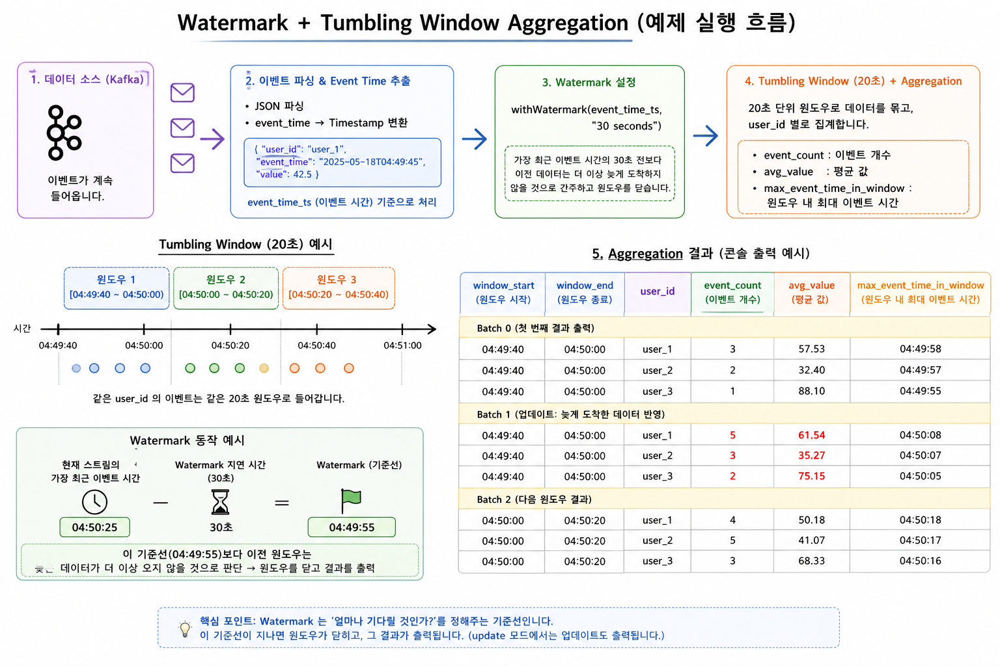

In [ ]:
# Watermark + Tumbling Window Aggregation 예제

# 현재 활성화된 모든 스트리밍 쿼리를 중지하여 이전 실행과의 충돌을 방지합니다.
stop_all_streams()
# 체크포인트 경로를 초기화합니다. 이는 스트리밍 쿼리의 상태를 저장하는 데 사용됩니다.
reset_path("/tmp/ckpt/watermark_window")

# events_df DataFrame을 사용하여 워터마크를 설정하고 윈도우 기반 집계를 수행합니다.
watermark_window_df = (
    events_df
    # 'event_time_ts' 컬럼을 기준으로 30초의 워터마크를 설정합니다.
    # 이는 이벤트 시간이 최대 30초 지연된 데이터까지 처리하도록 허용합니다.
    .withWatermark("event_time_ts", "30 seconds")
    # 'event_time_ts'를 기준으로 20초 크기의 텀블링 윈도우를 생성하고 'user_id'로 그룹화합니다.
    .groupBy(
        F.window("event_time_ts", "20 seconds").alias("time_window"), # 20초 텀블링 윈도우
        "user_id"
    )
    # 각 윈도우 및 사용자 ID별로 이벤트 수, 평균 값, 윈도우 내 최대 이벤트 시간을 집계합니다.
    .agg(
        F.count("*").alias("event_count"), # 이벤트 수
        F.avg("value").alias("avg_value"), # 평균 값
        F.max("event_time_ts").alias("max_event_time_in_window") # 윈도우 내 최대 이벤트 시간
    )
    # 최종 출력 컬럼을 선택하고, 윈도우 시작/종료 시간을 추출하며, 평균 값을 반올림합니다.
    .select(
        F.col("time_window.start").alias("window_start"), # 윈도우 시작 시간
        F.col("time_window.end").alias("window_end"), # 윈도우 종료 시간
        "user_id", "event_count",
        F.round("avg_value", 2).alias("avg_value"), # 소수점 둘째 자리까지 반올림된 평균 값
        "max_event_time_in_window"
    )
)

# 스트리밍 쿼리를 시작하여 윈도우 기반 집계 결과를 콘솔에 출력합니다.
query_watermark_window = (
    watermark_window_df.writeStream
    # .format("console") # 결과를 콘솔에 출력합니다.
    .foreachBatch(debug_batch)
    .outputMode("update") # 업데이트된 결과만 출력합니다 (새로운 집계 결과가 나올 때마다).
    .option("truncate", "false") # 출력 시 긴 문자열을 자르지 않도록 설정합니다.
    .option("numRows", 50) # 콘솔 출력 시 최대 50행까지 표시합니다.
    .option("checkpointLocation", "/tmp/ckpt/watermark_window") # 체크포인트 경로를 지정하여 내결함성을 제공합니다.
    .trigger(processingTime="10 seconds") # 10초마다 배치 처리를 트리거합니다.
    .start() # 스트리밍 쿼리를 시작합니다.
)

query_watermark_window.awaitTermination(40)

# 테스트를 위해 잠시 실행 후 종료합니다.
# time.sleep(40) # 40초 동안 실행하여 스트리밍 결과를 관찰합니다.
# query_watermark_window.stop() # 스트리밍 쿼리를 정지합니다.

In [ ]:
# Sliding Window 예제: 40초 크기의 윈도우가 10초마다 이동합니다.
# 동일 이벤트가 여러 윈도우에 포함될 수 있으므로 상태 크기가 증가합니다.

stop_all_streams()
reset_path("/tmp/ckpt/sliding_window")

sliding_window_df = (
    events_df
    .withWatermark("event_time_ts", "1 minute") # 'event_time_ts'를 기준으로 1분 워터마크 설정
    .groupBy(
        F.window("event_time_ts", "40 seconds", "10 seconds").alias("time_window"), # 40초 크기의 윈도우가 10초마다 슬라이딩
        "product_id"
    )
    .agg(
        F.sum("quantity").alias("total_quantity"), # 각 윈도우 내 총 수량 집계
        F.avg("price").alias("avg_price"), # 각 윈도우 내 평균 가격 집계
        F.count("*").alias("order_count") # 각 윈도우 내 주문 수 집계
    )
    .select(
        F.col("time_window.start").alias("window_start"), # 윈도우 시작 시간
        F.col("time_window.end").alias("window_end"), # 윈도우 종료 시간
        "product_id", "total_quantity",
        F.round("avg_price", 2).alias("avg_price"), # 소수점 둘째 자리까지 반올림된 평균 가격
        "order_count"
    )
)

query_sliding_window = (
    sliding_window_df.writeStream
    # .format("console") # 결과를 콘솔에 출력
    .foreachBatch(debug_batch)
    .outputMode("update") # 업데이트된 결과만 출력 (새로운 집계 결과가 나올 때마다)
    .option("truncate", "false") # 출력 시 긴 문자열을 자르지 않음
    .option("checkpointLocation", "/tmp/ckpt/sliding_window") # 체크포인트 경로 설정
    .trigger(processingTime="10 seconds") # 10초마다 배치 처리
    .start() # 스트리밍 쿼리 시작
)

query_sliding_window.awaitTermination(60)

# time.sleep(40) # 40초 동안 실행하여 스트리밍 결과를 관찰합니다.
# query_sliding_window.stop() # 스트리밍 쿼리를 정지합니다.

## 3. Stateful Processing vs Stateless Processing

- **Stateless Processing**: 각 레코드를 독립적으로 처리합니다. 예: `select`, `filter`, `withColumn`
- **Stateful Processing**: 이전 레코드나 누적 상태를 유지해야 합니다. 예: `groupBy`, `window`, `join`

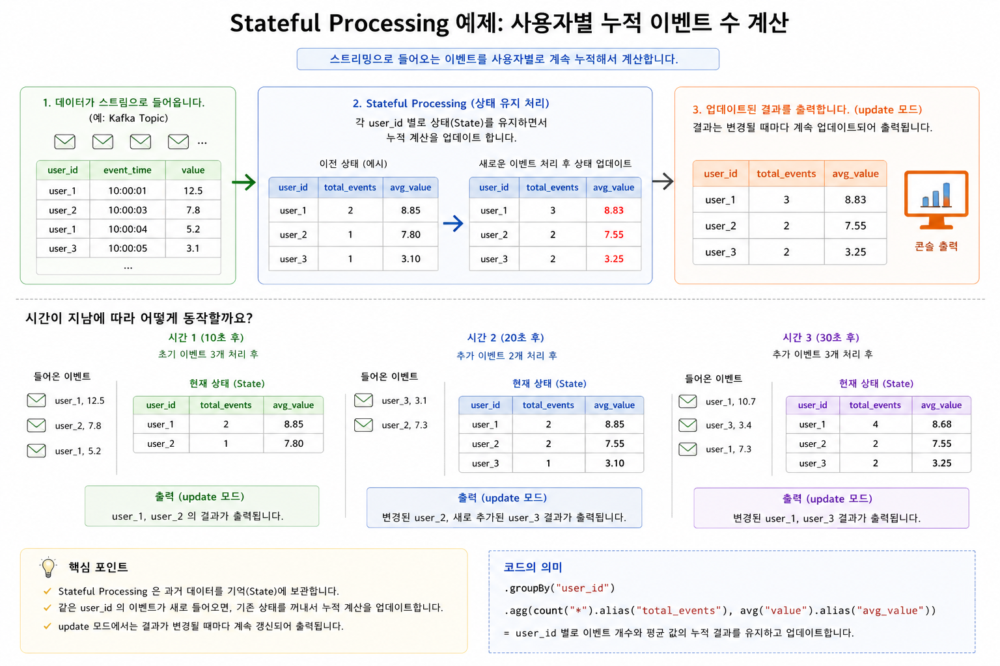

In [ ]:
# Stateless Processing 예제: purchase 이벤트만 필터링하고 컬럼만 변환합니다.

stop_all_streams()
reset_path("/tmp/ckpt/stateless_filter")

stateless_df = (
    events_df
    .filter(F.col("event_type") == "purchase")
    .select(
        "event_id", "user_id", "product_id", "event_type",
        "event_time_ts",
        (F.col("quantity") * F.col("price")).alias("amount")
    )
)

query_stateless = (
    stateless_df.writeStream
    # .format("console")
    .foreachBatch(debug_batch)
    .outputMode("append")
    .option("truncate", "false")
    .option("checkpointLocation", "/tmp/ckpt/stateless_filter")
    .trigger(processingTime="10 seconds")
    .start()
)

query_stateless.awaitTermination(30)

# time.sleep(30)
# query_stateless.stop()

In [ ]:
# Stateful Processing 예제: 사용자별 누적 이벤트 수를 계산합니다.

stop_all_streams()
reset_path("/tmp/ckpt/stateful_count_by_user")

stateful_df = (
    events_df
    .groupBy("user_id")
    .agg(
        F.count("*").alias("total_events"),
        F.avg("value").alias("avg_value")
    )
)

query_stateful = (
    stateful_df.writeStream
    # .format("console")
    .foreachBatch(debug_batch)
    .outputMode("update")
    .option("truncate", "false")
    .option("checkpointLocation", "/tmp/ckpt/stateful_count_by_user")
    .trigger(processingTime="10 seconds")
    .start()
)

query_stateful.awaitTermination(30)

time.sleep(30)
query_stateful.stop()

## 4. Checkpoint 예제

Checkpoint는 offset, state, metadata를 저장하여 장애 발생 후에도 마지막 처리 지점부터 복구할 수 있게 합니다.

- 같은 query를 재시작하려면 같은 checkpoint 경로를 유지합니다.
- 실습을 처음부터 다시 하고 싶을 때만 checkpoint 디렉토리를 삭제합니다.
- 운영 환경에서는 `/tmp` 대신 HDFS, S3, DBFS 등 안정적인 저장소를 사용합니다.

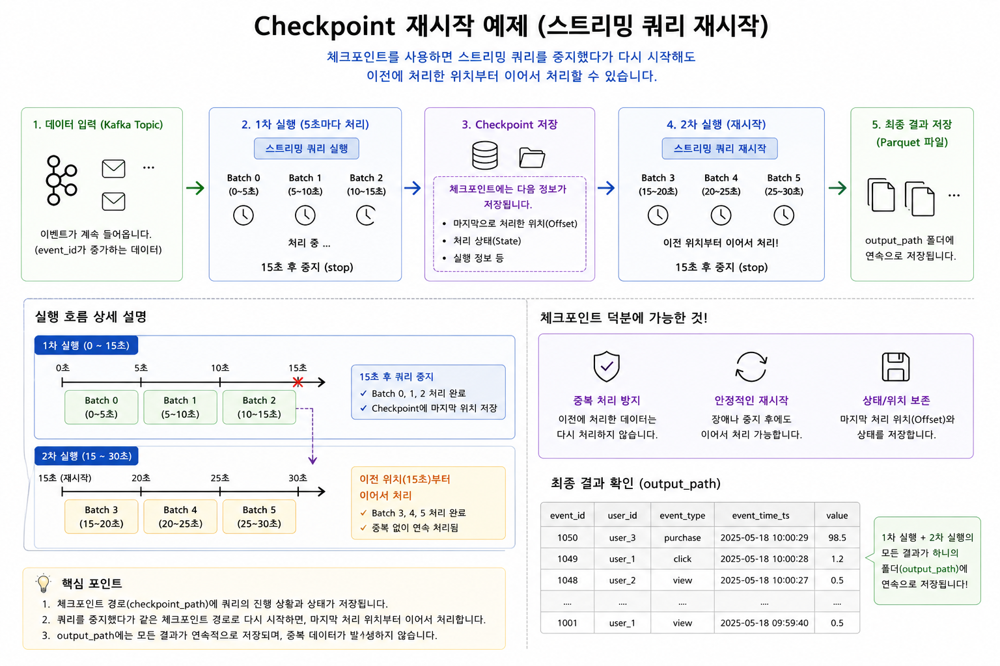

In [ ]:
# Checkpoint 재시작 예제

stop_all_streams()

checkpoint_path = "/tmp/ckpt/checkpoint_restart_demo"
output_path = "/tmp/output/checkpoint_restart_demo"

# 처음부터 실습하려면 아래 두 줄을 실행합니다.
reset_path(checkpoint_path)
reset_path(output_path)

checkpoint_demo_df = (
    events_df
    .select("event_id", "user_id", "event_type", "event_time_ts", "value")
)

query_ckpt_1 = (
    checkpoint_demo_df.writeStream
    .format("parquet")
    .outputMode("append")
    .option("path", output_path)
    .option("checkpointLocation", checkpoint_path)
    .trigger(processingTime="5 seconds")
    .start()
)

time.sleep(15)
query_ckpt_1.stop()
print("1차 실행 종료")

query_ckpt_2 = (
    checkpoint_demo_df.writeStream
    .format("parquet")
    .outputMode("append")
    .option("path", output_path)
    .option("checkpointLocation", checkpoint_path)
    .trigger(processingTime="5 seconds")
    .start()
)

time.sleep(15)
query_ckpt_2.stop()
print("2차 실행 종료: 같은 checkpoint 기준으로 이어서 처리됨")

spark.read.parquet(output_path).orderBy(F.desc("event_time_ts")).show(20, truncate=False)

## 5. Output Modes: Append, Update, Complete

- `append`: 새로 확정된 행만 출력합니다.
- `update`: 변경된 행만 출력합니다.
- `complete`: 매 trigger마다 전체 결과 테이블을 출력합니다.

In [ ]:
# Output Mode 1: Append

stop_all_streams()
reset_path("/tmp/ckpt/output_append")

append_df = events_df.select("event_id", "user_id", "event_type", "event_time_ts")

query_append = (
    append_df.writeStream
    .format("console")
    .outputMode("append")
    .option("truncate", "false")
    .option("checkpointLocation", "/tmp/ckpt/output_append")
    .trigger(processingTime="10 seconds")
    .start()
)

time.sleep(20)
query_append.stop()

In [ ]:
# Output Mode 2: Update

stop_all_streams()
reset_path("/tmp/ckpt/output_update")

update_df = (
    events_df
    .withWatermark("event_time_ts", "30 seconds")
    .groupBy(F.window("event_time_ts", "20 seconds"), "event_type")
    .count()
)

query_update = (
    update_df.writeStream
    .format("console")
    .outputMode("update")
    .option("truncate", "false")
    .option("checkpointLocation", "/tmp/ckpt/output_update")
    .trigger(processingTime="10 seconds")
    .start()
)

time.sleep(30)
query_update.stop()

In [ ]:
# Output Mode 3: Complete

stop_all_streams()
reset_path("/tmp/ckpt/output_complete")

complete_df = (
    events_df
    .groupBy("event_type")
    .agg(F.count("*").alias("cnt"), F.avg("value").alias("avg_value"))
)

query_complete = (
    complete_df.writeStream
    .format("console")
    .outputMode("complete")
    .option("truncate", "false")
    .option("checkpointLocation", "/tmp/ckpt/output_complete")
    .trigger(processingTime="10 seconds")
    .start()
)

time.sleep(30)
query_complete.stop()

## 6. Stream-Stream Join

두 개의 실시간 스트림을 조인할 때는 다음 조건이 필요합니다.

1. 양쪽 스트림 모두 Watermark 설정
2. 조인 키 조건
3. Event Time 기반 시간 범위 조건

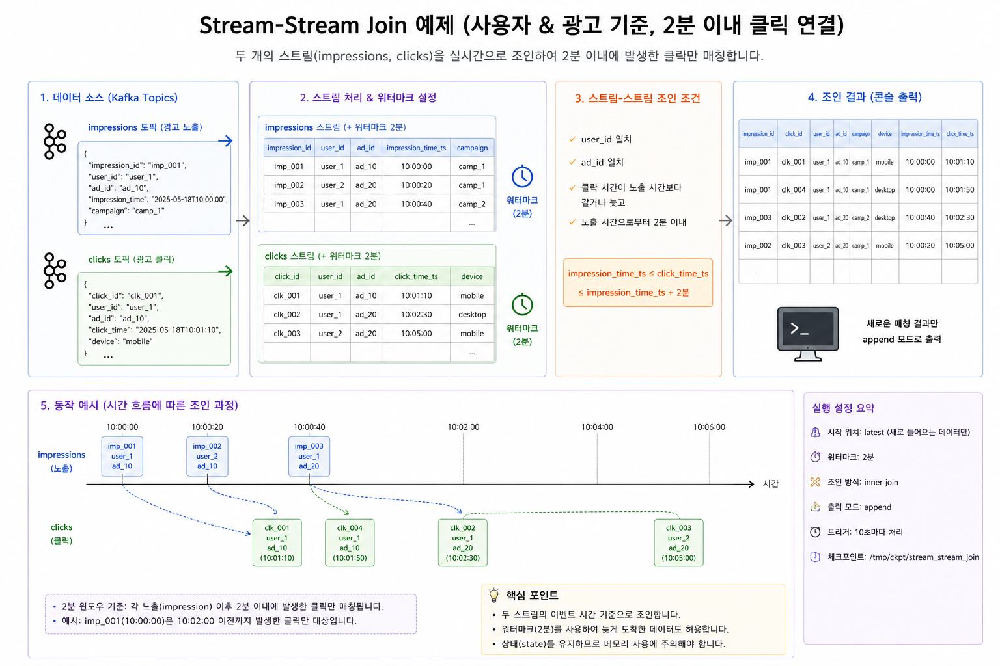

In [ ]:
# Stream-Stream Join 예제

# 모든 활성 스트리밍 쿼리를 정지합니다. (이전 실행으로 인한 충돌 방지)
stop_all_streams()
# 체크포인트 디렉토리를 초기화합니다. (재실행 시 클린 상태 유지)
reset_path("/tmp/ckpt/stream_stream_join")

# impressions 토픽 메시지의 스키마를 정의합니다.
impression_schema = StructType([
    StructField("impression_id", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("ad_id", StringType(), True),
    StructField("impression_time", StringType(), True), # ISO 8601 형식의 노출 시간
    StructField("campaign", StringType(), True),
])

# clicks 토픽 메시지의 스키마를 정의합니다.
click_schema = StructType([
    StructField("click_id", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("ad_id", StringType(), True),
    StructField("click_time", StringType(), True), # ISO 8601 형식의 클릭 시간
    StructField("device", StringType(), True),
])

# Kafka에서 'impressions' 토픽의 스트림 데이터를 읽기 위한 설정을 정의합니다.
raw_impressions = (
    spark.readStream.format("kafka")
    .option("kafka.bootstrap.servers", BOOTSTRAP)
    .option("subscribe", "impressions")
    .option("startingOffsets", "latest") # 새로 들어오는 메시지만 읽도록 설정
    .load()
)

# Kafka에서 'clicks' 토픽의 스트림 데이터를 읽기 위한 설정을 정의합니다.
raw_clicks = (
    spark.readStream.format("kafka")
    .option("kafka.bootstrap.servers", BOOTSTRAP)
    .option("subscribe", "clicks")
    .option("startingOffsets", "latest") # 새로 들어오는 메시지만 읽도록 설정
    .load()
)

# impressions 스트림 데이터를 파싱하고 워터마크를 설정합니다.
impressions_df = (
    raw_impressions
    .select(F.from_json(F.col("value").cast("string"), impression_schema).alias("data"))
    .select("data.*")
    .withColumn("impression_time_ts", F.to_timestamp("impression_time")) # ISO 8601 문자열을 TimestampType으로 변환
    .withWatermark("impression_time_ts", "2 minutes") # 'impression_time_ts'를 기준으로 2분 워터마크 설정
)

# clicks 스트림 데이터를 파싱하고 워터마크를 설정합니다.
clicks_df = (
    raw_clicks
    .select(F.from_json(F.col("value").cast("string"), click_schema).alias("data"))
    .select("data.*")
    .withColumn("click_time_ts", F.to_timestamp("click_time")) # ISO 8601 문자열을 TimestampType으로 변환
    .withWatermark("click_time_ts", "2 minutes") # 'click_time_ts'를 기준으로 2분 워터마크 설정
)

# 두 스트림(impressions와 clicks)을 조인합니다.
# - 조인 키: user_id와 ad_id
# - 시간 조건: 클릭 시간이 노출 시간보다 같거나 늦고, 노출 시간으로부터 2분 이내여야 합니다.
joined_df = (
    impressions_df.alias("i") # impressions DataFrame에 'i'라는 별칭 부여
    .join(
        clicks_df.alias("c"), # clicks DataFrame에 'c'라는 별칭 부여
        on=[
            F.col("i.user_id") == F.col("c.user_id"), # 사용자 ID 일치
            F.col("i.ad_id") == F.col("c.ad_id"), # 광고 ID 일치
            F.col("c.click_time_ts") >= F.col("i.impression_time_ts"), # 클릭 시간이 노출 시간보다 늦거나 같음
            F.col("c.click_time_ts") <= F.col("i.impression_time_ts") + F.expr("INTERVAL 2 minutes") # 클릭 시간이 노출 시간 후 2분 이내
        ],
        how="inner" # 내부 조인 (양쪽에 모두 존재하는 레코드만 반환)
    )
    .select(
        F.col("i.impression_id"), # 노출 ID
        F.col("c.click_id"), # 클릭 ID
        F.col("i.user_id"), # 사용자 ID
        F.col("i.ad_id"), # 광고 ID
        F.col("i.campaign"), # 캠페인 정보
        F.col("c.device"), # 클릭 장치 정보
        F.col("i.impression_time_ts"), # 노출 시간 타임스탬프
        F.col("c.click_time_ts") # 클릭 시간 타임스탬프
    )
)

# 조인된 스트림 쿼리를 시작하여 결과를 콘솔에 출력합니다.
query_join = (
    joined_df.writeStream
    # .format("console") # 결과를 콘솔에 출력
    .foreachBatch(debug_batch)
    .outputMode("append") # 새로운 조인 결과만 출력
    .option("truncate", "false") # 출력 시 긴 문자열을 자르지 않음
    .option("checkpointLocation", "/tmp/ckpt/stream_stream_join") # 체크포인트 경로 설정
    .trigger(processingTime="10 seconds") # 10초마다 배치 처리
    .start() # 스트리밍 쿼리 시작
)

query_join.awaitTermination(120)

# # 테스트를 위해 잠시 실행 후 종료
# import time
# time.sleep(60) # 60초 동안 실행하여 결과 확인
# query_join.stop() # 스트리밍 쿼리 정지

# Stream Join이 필요한 시나리오

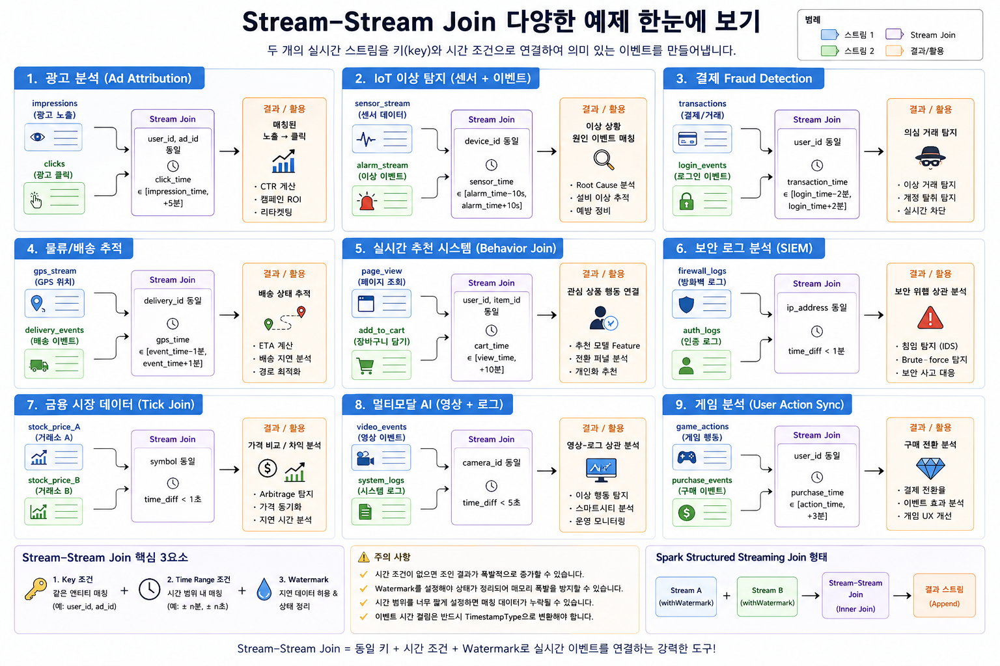

# 한번더 체크

## Window Operations (추가 설명)

이전에 Watermark와 Window Aggregation에 대한 예제를 만들었지만, Tumbling Window와 Sliding Window를 명확히 구분하고 그 동작 방식을 이해하는 것이 중요합니다.

*   `window(timeColumn, windowDuration, slideDuration)`
    *   `timeColumn`: 이벤트 시간 열.
    *   `windowDuration`: 윈도우의 총 길이 (예: '10 seconds').
    *   `slideDuration`: 윈도우가 얼마나 자주 이동하는지 (예: '5 seconds').

만약 `slideDuration`을 생략하거나 `windowDuration`과 동일하게 설정하면, 이는 Tumbling Window처럼 동작합니다. `slideDuration`이 `windowDuration`보다 작으면 Sliding Window가 됩니다.

## Tumbling Window (텀블링 윈도우)

텀블링 윈도우는 **고정된 크기**와 **겹치지 않는(non-overlapping)** 특성을 가진 윈도우입니다. 각 데이터 레코드는 정확히 하나의 윈도우에 속하게 됩니다. 예를 들어, 10초 텀블링 윈도우는 0-10초, 10-20초, 20-30초와 같이 연속적인 시간 구간을 형성합니다.

### 운영상의 영향 (Operational Impact)

*   **심플한 집계:** 각 데이터가 하나의 윈도우에만 속하므로, 집계 로직이 단순하고 결과를 이해하기 쉽습니다.
*   **정기적인 결과:** 윈도우 간격에 따라 주기적으로 결과가 생성됩니다. (예: 10초마다 지난 10초간의 총합)
*   **리소스 효율성:** 윈도우가 겹치지 않으므로, 중복 계산이 적어 리소스 사용 측면에서 효율적일 수 있습니다.
*   **지연된 데이터 처리:** Watermark와 함께 사용하면, 특정 지연 시간까지 윈도우가 열려 있어 지연된 데이터도 올바르게 처리될 수 있습니다. 윈도우가 닫히면 더 이상 해당 윈도우의 데이터는 처리되지 않습니다.
*   **데이터 흐름:** 데이터가 도착하면 해당 윈도우에 할당되고, 윈도우가 닫히고 Watermark를 넘어서면 최종 결과가 업데이트 모드로 출력됩니다.

## Sliding Window (슬라이딩 윈도우)

슬라이딩 윈도우는 **고정된 크기**를 가지지만, **겹치는(overlapping)** 윈도우입니다. 윈도우는 일정 간격(슬라이드 간격)으로 앞으로 이동하며, 이로 인해 여러 윈도우가 동일한 데이터 레코드를 포함할 수 있습니다. 예를 들어, 10초 윈도우가 5초마다 슬라이딩하면, 0-10초, 5-15초, 10-20초와 같이 윈도우가 겹치게 됩니다.

### 운영상의 영향 (Operational Impact)

*   **실시간에 가까운 분석:** 윈도우가 겹치므로, 텀블링 윈도우보다 더 자주 업데이트된 집계 결과를 얻을 수 있어 실시간에 가까운 분석에 유리합니다.
*   **트렌드 및 패턴 감지:** 윈도우 간의 중첩을 통해 단기적인 트렌드나 패턴 변화를 더 민감하게 감지할 수 있습니다.
*   **리소스 사용:** 윈도우가 겹치기 때문에 동일한 데이터를 여러 번 처리할 수 있어 텀블링 윈도우보다 더 많은 리소스를 소비할 수 있습니다.
*   **결과 일관성:** `update` 모드 사용 시, 윈도우가 슬라이딩할 때마다 해당 윈도우의 업데이트된 집계 결과가 출력됩니다.
*   **지연된 데이터 처리:** Watermark와 함께 사용하면 텀블링 윈도우와 유사하게 지연된 데이터를 처리할 수 있지만, 겹치는 윈도우의 특성상 더 많은 윈도우가 영향을 받을 수 있습니다.